In [1]:
import tensorflow as tf
print(tf.__version__)


C:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/

2.20.0


In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import matplotlib.pyplot as plt


In [3]:
IMG_SIZE = 224
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    "digits",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training"
)

val_data = datagen.flow_from_directory(
    "digits",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation"
)


Found 1201 images belonging to 10 classes.
Found 300 images belonging to 10 classes.


In [4]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


C:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │      11,075,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,170,250 (42.61 MB)

 Trainable params: 11,170,250 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15
)


Epoch 1/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.3097 - loss: 2.0437 - val_accuracy: 0.7667 - val_loss: 0.9085
Epoch 2/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.8018 - loss: 0.6066 - val_accuracy: 0.9167 - val_loss: 0.3447
Epoch 3/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.9276 - loss: 0.2518 - val_accuracy: 0.9767 - val_loss: 0.0693
Epoch 4/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.9667 - loss: 0.1028 - val_accuracy: 0.9833 - val_loss: 0.0683
Epoch 5/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.9792 - loss: 0.0685 - val_accuracy: 0.9767 - val_loss: 0.0909
Epoch 6/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.9808 - loss: 0.0752 - val_accuracy: 0.9867 - val_loss: 0.0517
Epoch 7/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.9750 - loss: 0.0651 - val_accuracy: 0.9800 - val_loss: 0.0690
Epoch 8/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.9900 - loss: 0.0283 - val_accuracy: 0.9900 - val_loss:

In [6]:
model.save("digit_model.h5")


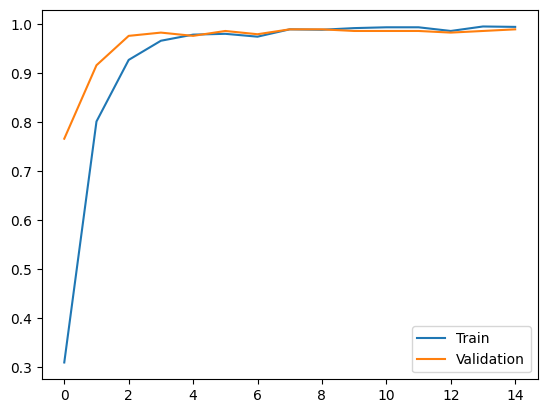

In [7]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(["Train","Validation"])
plt.show()


In [ ]:
import cv2
import numpy as np
import tensorflow as tf

model = tf.keras.models.load_model("digit_model.h5")
IMG_SIZE = 224

cap = cv2.VideoCapture(0)

print("Press SPACE to capture and predict")
print("Press Q to quit")

while True:
    ret, frame = cap.read()
    frame = cv2.flip(frame,1)

    x1,y1,x2,y2 = 100,100,400,400
    cv2.rectangle(frame,(x1,y1),(x2,y2),(0,255,0),2)

    cv2.imshow("Digit Prediction", frame)

    key = cv2.waitKey(1)

    # When SPACE is pressed → capture once
    if key == 32:
        hand = frame[y1:y2, x1:x2]
        hand = cv2.resize(hand,(IMG_SIZE,IMG_SIZE))
        hand = hand/255.0
        hand = np.expand_dims(hand,axis=0)

        pred = model.predict(hand)
        digit = np.argmax(pred)
        confidence = np.max(pred)

        print("Predicted Digit:", digit)
        print("Confidence:", confidence)

    # Quit
    if key == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()



Press SPACE to capture and predict
Press Q to quit
